In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\moham\.cache\kagglehub\datasets\robikscube\hourly-energy-consumption\versions\3


In [ ]:
Dataset = path

print(os.listdir(Dataset))

['AEP_hourly.csv', 'COMED_hourly.csv', 'DAYTON_hourly.csv', 'DEOK_hourly.csv', 'DOM_hourly.csv', 'DUQ_hourly.csv', 'EKPC_hourly.csv', 'est_hourly.paruqet', 'FE_hourly.csv', 'NI_hourly.csv', 'PJME_hourly.csv', 'PJMW_hourly.csv', 'pjm_hourly_est.csv', 'PJM_Load_hourly.csv']


In [ ]:
path = os.path.join(Dataset, "PJME_hourly.csv")

In [ ]:
# Read CSV file into DataFrame and convert the first column to datetime
df = pd.read_csv(path, index_col=0, parse_dates=True)

# Create a backup copy of the DataFrame (raw, untouched)
df_copy = df.copy()

## Data Exploration

In [ ]:
# Sort data chronologically
df = df.sort_values("Datetime")

print(df.shape)

display(df.head())

print(df.info())

display(df.describe())

(145366, 1)


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145366 entries, 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB
None


,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


## Data Quality Checks

In [24]:
# Check for duplicate timestamps
df.index.duplicated().sum()

np.int64(0)

In [ ]:
# Display duplicate timestamps
df[df.index.duplicated(keep=False)]

,PJME_MW
Datetime,
2014-11-02 02:00:00,23755.0
2014-11-02 02:00:00,22935.0
2015-11-01 02:00:00,21567.0
2015-11-01 02:00:00,21171.0
2016-11-06 02:00:00,20795.0
2016-11-06 02:00:00,21692.0
2017-11-05 02:00:00,21236.0
2017-11-05 02:00:00,20666.0


In [44]:
# Check the time difference between consecutive observations
df.index.to_series().diff().value_counts()

Out[9]

Datetime
0 days 01:00:00    145331
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64

### DST Handling Decision

Resolves DST duplicates and missing hourly gaps by keeping the **first occurrence** and applying **linear interpolation**.

In [ ]:
# Remove duplicate timestamps (keep first occurrence)
df = df[~df.index.duplicated(keep="first")]

(145392, 1)
Missing values after fix: PJME_MW    0
dtype: int64


In [ ]:
# Build a complete hourly index and reindex onto it
full_range = pd.date_range(df.index.min(),
                           df.index.max(),
                           freq="h")
df = df.reindex(full_range)
df.index.name = "Datetime"

In [ ]:
# Fill the resulting gaps (DST + the 2010-12-10 anomaly) via linear interpolation
df["PJME_MW"] = df["PJME_MW"].interpolate(method="linear")

print(df.shape)
print("Missing values after fix:", df.isnull().sum())

(145392, 1)
Missing values after fix: PJME_MW    0
dtype: int64


## EDA
Using a separate `eda_df` for datetime-feature exploration, so the main `df` used for modeling stays univariate (`PJME_MW` only).

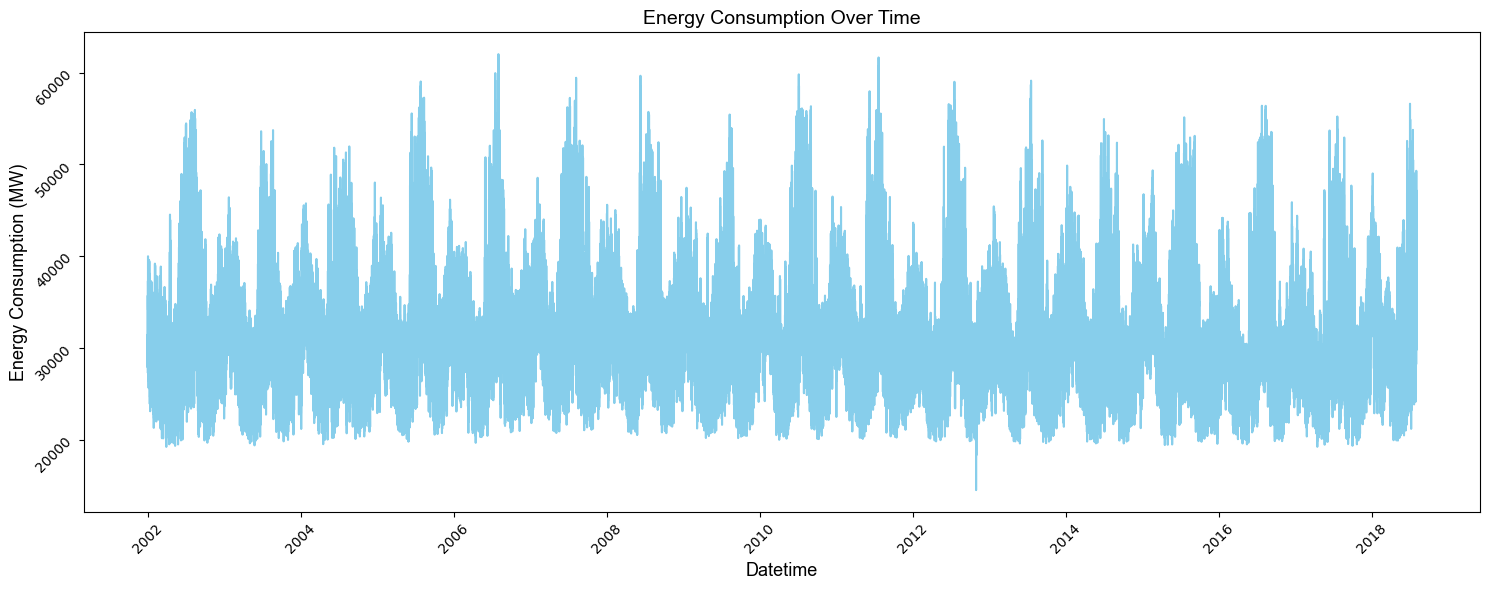

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(df.index, df['PJME_MW'],
         color='skyblue')

plt.xlabel('Datetime',
           family="Arial",
           size=13,
           )

plt.ylabel('Energy Consumption (MW)',
           family="Arial",
           size=13,
           )
plt.title('Energy Consumption Over Time',
          family="Arial",
          size=14,)

plt.xticks(rotation=45)
plt.yticks(rotation=45)

plt.tight_layout()
plt.show()

In [47]:
# Separate copy for EDA feature engineering — keeps df clean for modeling
eda_df = df.copy()
eda_df["hour"] = eda_df.index.hour
eda_df["day_of_week"] = eda_df.index.dayofweek
eda_df["month"] = eda_df.index.month

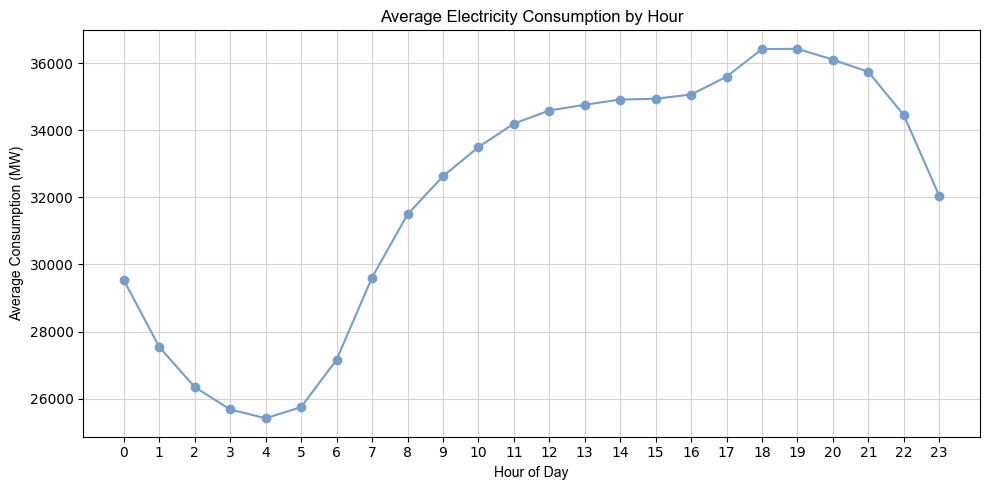

In [48]:
hourly_avg = eda_df.groupby("hour")["PJME_MW"].mean()

plt.figure(figsize=(10, 5))

plt.grid(axis="both",
         color="lightgray")

plt.plot(
    hourly_avg.index,
    hourly_avg.values,
    color="#779ecb",
    marker="o",
)

plt.xlabel("Hour of Day", family="Arial")
plt.ylabel("Average Consumption (MW)", family="Arial")
plt.title("Average Electricity Consumption by Hour", family="Arial")

plt.xticks(range(24))

plt.tight_layout()
plt.show()

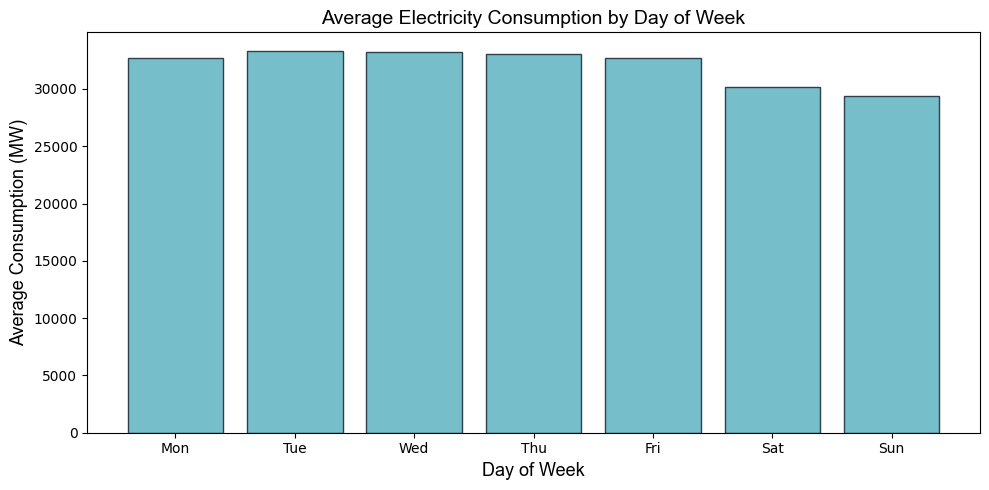

In [ ]:
weekly_avg = eda_df.groupby("day_of_week")["PJME_MW"].mean()

plt.figure(figsize=(10, 5))

plt.bar(
    weekly_avg.index,
    weekly_avg.values,
    color="#77becb",
    edgecolor="#2c4050",
)

plt.xlabel("Day of Week", family="Arial", size=13)
plt.ylabel("Average Consumption (MW)", family="Arial", size=13)
plt.title("Average Electricity Consumption by Day of Week",
          family="Arial", size=14)

days_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
plt.xticks(range(7), labels=days_labels)

plt.tight_layout()
plt.show()

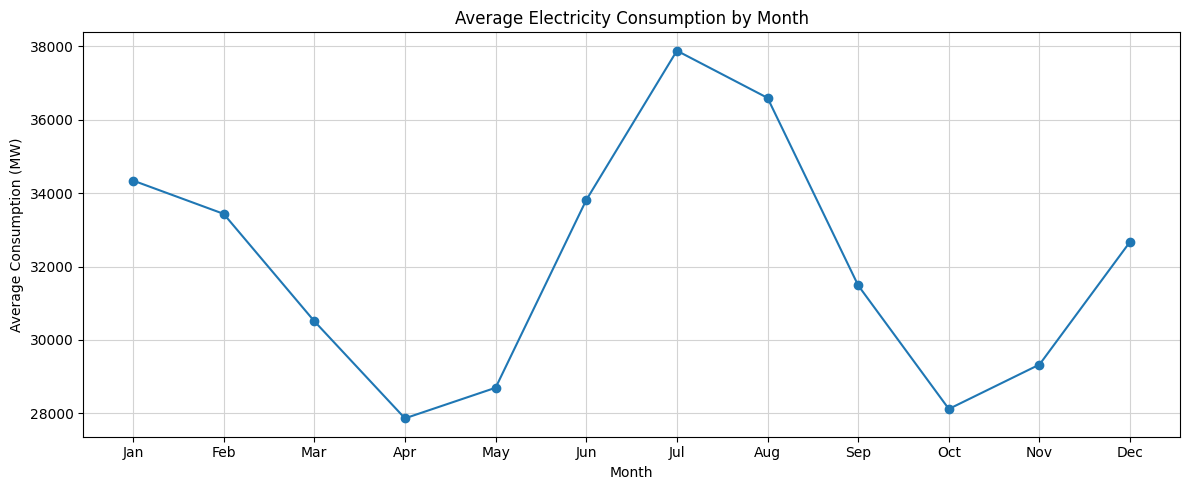

In [ ]:
monthly_avg = eda_df.groupby("month")["PJME_MW"].mean()

plt.figure(figsize=(12, 5))

plt.grid(
    axis='both',
    color='lightgray'
)

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Consumption (MW)")
plt.title("Average Electricity Consumption by Month")

months = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]
plt.xticks(range(1, 13), months)

plt.tight_layout()
plt.show()

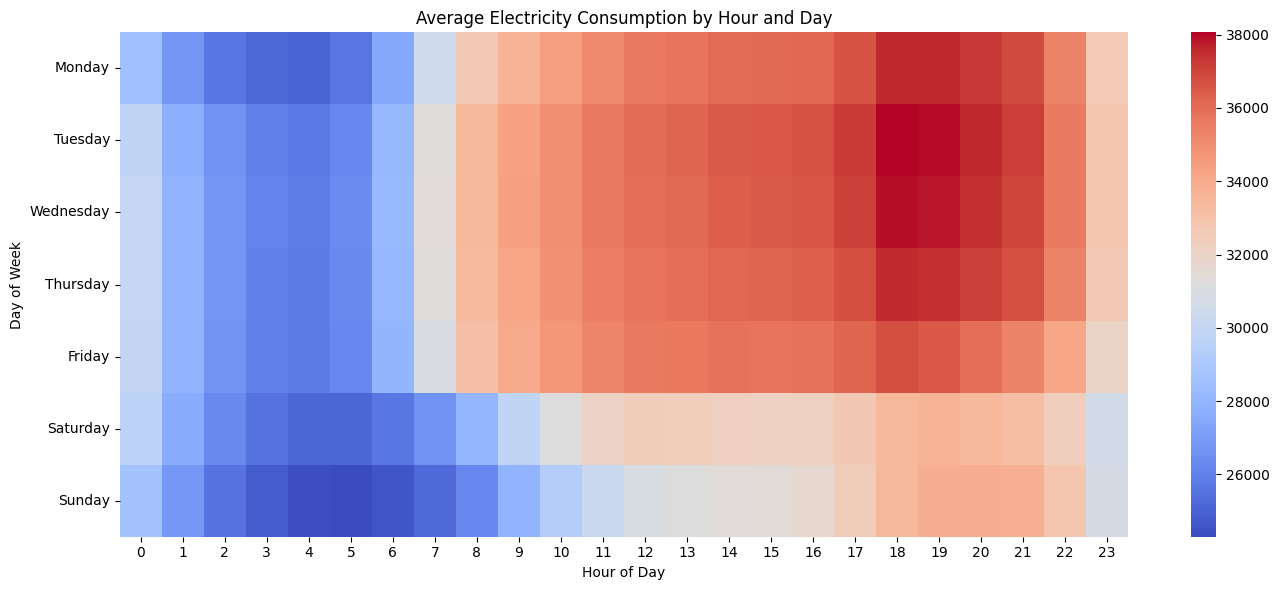

In [51]:
heatmap_data = eda_df.pivot_table(
    values="PJME_MW",
    index="day_of_week",
    columns="hour",
    aggfunc="mean"
)

heatmap_data.index = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
)

plt.title("Average Electricity Consumption by Hour and Day")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.tight_layout()
plt.show()

In [ ]:
print(df.columns.tolist())
print(df.shape)

['PJME_MW']
(145392, 1)


## Chronological Data Splitting

Splits the dataset sequentially into **Train (80%)**, **Validation (10%)**, and **Test (10%)** sets without shuffling to preserve time-series order

In [ ]:
# Split the data chronologically into train, validation, and test sets
train_size = int(len(df) * 0.8)
val_size = int(len(df) * 0.1)

train = df.iloc[:train_size]
val = df.iloc[train_size:train_size + val_size]
test = df.iloc[train_size + val_size:]

print("Train:", train.shape)
print("Val:", val.shape)
print("Test:", test.shape)

Train: (116313, 1)
Val: (14539, 1)
Test: (14540, 1)


## Feature Scaling (MinMaxScaler)

Normalizes features to a **[0, 1]** range using `fit_transform` on the training set only to prevent data leakage.

In [52]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

train_scaled = scaler.fit_transform(train)

val_scaled = scaler.transform(val)
test_scaled = scaler.transform(test)

print("Train scaled range:", train_scaled.min(), "to", train_scaled.max())
print("Test scaled range: ", test_scaled.min(), "to", test_scaled.max())

Train scaled range: 0.0 to 1.0
Test scaled range:  0.09925208048035394 to 0.8862319603918676


## Create Sequence Data (Lookback Window)

Converts time-series data into **24-hour lookback sequences** ($X$) and next-hour targets ($y$) for LSTM training.

In [ ]:
lookback = 24

def create_sequences(data, lookback):
    X = []
    y = []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])

    return np.array(X), np.array(y)


# creat a seqyences
X_train, y_train = create_sequences(train_scaled, lookback)

X_val, y_val = create_sequences(val_scaled, lookback)

X_test, y_test = create_sequences(test_scaled, lookback)


# check from shape
print("X_train:", X_train.shape)
print("y_train:", y_train.shape, '\n')

print("X_val:", X_val.shape)
print("y_val:", y_val.shape, '\n')

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (116289, 24, 1)
y_train: (116289, 1) 

X_val: (14515, 24, 1)
y_val: (14515, 1) 

X_test: (14516, 24, 1)
y_test: (14516, 1)


## Create LSTM Baseline Model

Builds a baseline **Sequential LSTM model** with 50 units followed by a Single Dense output layer for next-step forecasting.

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# creat a model
model = Sequential()

# LSTM Layer
model.add(
    LSTM(
        units=50,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

# Output Layer
model.add(
    Dense(units=1)
)

model.summary()

c:\Users\moham\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

## Compile and Train Model with Early Stopping

Compiles the LSTM model with Adam optimizer and MSE loss, then trains it for up to 50 epochs using **Early Stopping** to prevent overfitting.

In [57]:
from tensorflow.keras.callbacks import EarlyStopping

# Compile
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Training
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/50
3635/3635 ━━━━━━━━━━━━━━━━━━━━ 31s 8ms/step - loss: 0.0016 - val_loss: 2.4692e-04
Epoch 2/50
3635/3635 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 2.0444e-04 - val_loss: 0.0013
Epoch 3/50
3635/3635 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 1.5910e-04 - val_loss: 1.3943e-04
Epoch 4/50
3635/3635 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 1.3758e-04 - val_loss: 8.0609e-05
Epoch 5/50
3635/3635 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 1.1348e-04 - val_loss: 8.1832e-05
Epoch 6/50
3635/3635 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 9.9439e-05 - val_loss: 7.6088e-05
Epoch 7/50
3635/3635 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 9.1259e-05 - val_loss: 6.0755e-05
Epoch 8/50
3635/3635 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 8.3064e-05 - val_loss: 8.3170e-05
Epoch 9/50
3635/3635 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 7.6186e-05 - val_loss: 5.7326e-05
Epoch 10/50
3635/3635 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - loss: 7.1076e-05 - val_loss: 9.2262e-05
Epoch 11/50
3635/3635 ━━━━━━━━━━━━━━━

## Model Evaluation and Inverse Scaling

In [58]:
# 1. Make predictions on the test set
predictions_scaled = model.predict(X_test)

# 2. Convert predictions back to the original MW scale
predictions = scaler.inverse_transform(predictions_scaled)

# 3. Convert true values back to the original MW scale
y_test_original = scaler.inverse_transform(y_test)

# Check the shapes
print("Predictions shape:", predictions.shape)
print("True values shape:", y_test_original.shape)

454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Predictions shape: (14516, 1)
True values shape: (14516, 1)


## Calculate MAE and RMSE Metrics

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_original, predictions)

rmse = np.sqrt(mean_squared_error(y_test_original, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 209.88922931485087
RMSE: 293.99398196194795


## Save Model and Scaler

In [ ]:
import joblib

model.save("pjme_lstm_model.keras")

joblib.dump(scaler, "pjme_scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
